In [ ]:
# supply chain disruption risk
import pandas as pd
df=pd.read_csv('supply_chain_data.csv')
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [2]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [3]:
features = [
    'Stock levels',
    'Lead times',
    'Order quantities',
    'Shipping times',
    'Shipping costs',
    'Supplier name',
    'Transportation modes',
    'Production volumes',
    'Manufacturing lead time',
    'Defect rates'
]
target = ['Inspection results']

In [4]:
# keep only the following columns in the dataset: 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Supplier name', 'Transportation modes', 'Production volumes', 'Manufacturing lead time', 'Defect rates', and 'Inspection results'.   
df = df[features + target]

In [5]:
df

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Supplier name,Transportation modes,Production volumes,Manufacturing lead time,Defect rates,Inspection results
0,58,7,96,4,2.956572,Supplier 3,Road,215,29,0.226410,Pending
1,53,30,37,2,9.716575,Supplier 3,Road,517,30,4.854068,Pending
2,1,10,88,2,8.054479,Supplier 1,Air,971,27,4.580593,Pending
3,23,13,59,6,1.729569,Supplier 5,Rail,937,18,4.746649,Fail
4,5,3,56,8,3.890548,Supplier 1,Air,414,3,3.145580,Fail
...,...,...,...,...,...,...,...,...,...,...,...
95,15,14,26,9,8.630339,Supplier 4,Air,450,26,1.210882,Pending
96,67,2,32,3,5.352878,Supplier 3,Road,648,28,3.872048,Pending
97,46,19,4,9,7.904846,Supplier 4,Road,535,13,3.376238,Fail
98,53,1,27,7,1.409801,Supplier 5,Rail,581,9,2.908122,Pending


In [6]:
df.describe()

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Production volumes,Manufacturing lead time,Defect rates
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,47.770000,15.960000,49.220000,5.750000,5.548149,567.840000,14.77000,2.277158
std,31.369372,8.785801,26.784429,2.724283,2.651376,263.046861,8.91243,1.461366
min,0.000000,1.000000,1.000000,1.000000,1.013487,104.000000,1.00000,0.018608
25%,16.750000,8.000000,26.000000,3.750000,3.540248,352.000000,7.00000,1.009650
50%,47.500000,17.000000,52.000000,6.000000,5.320534,568.500000,14.00000,2.141863
75%,73.000000,24.000000,71.250000,8.000000,7.601695,797.000000,23.00000,3.563995
max,100.000000,30.000000,96.000000,10.000000,9.929816,985.000000,30.00000,4.939255


<Axes: >

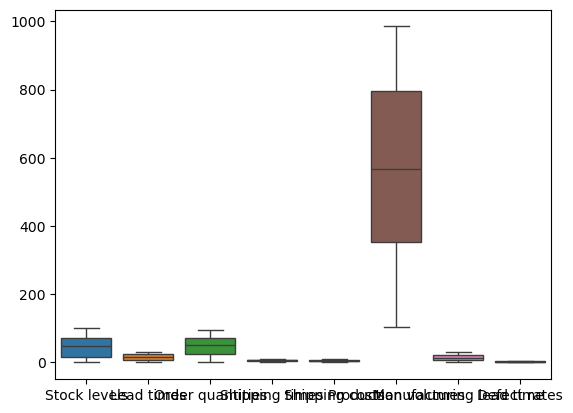

In [7]:
import seaborn as sns
sns.boxplot(df)

In [8]:
df.head()

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Supplier name,Transportation modes,Production volumes,Manufacturing lead time,Defect rates,Inspection results
0,58,7,96,4,2.956572,Supplier 3,Road,215,29,0.226410,Pending
1,53,30,37,2,9.716575,Supplier 3,Road,517,30,4.854068,Pending
2,1,10,88,2,8.054479,Supplier 1,Air,971,27,4.580593,Pending
3,23,13,59,6,1.729569,Supplier 5,Rail,937,18,4.746649,Fail
4,5,3,56,8,3.890548,Supplier 1,Air,414,3,3.145580,Fail


In [9]:
df['Supplier name'].value_counts()

Supplier name
Supplier 1    27
Supplier 2    22
Supplier 5    18
Supplier 4    18
Supplier 3    15
Name: count, dtype: int64

In [10]:
# use one-hot encoding to convert the 'Transportation modes' column into numerical format.
df = pd.get_dummies(df, columns=['Supplier name'])

In [11]:
# In Supplier name_Supplier 1	Supplier name_Supplier 2	Supplier name_Supplier 3	Supplier name_Supplier 4	Supplier name_Supplier 5 replace true with 1 and false with 0
df['Supplier name_Supplier 1'] = df['Supplier name_Supplier 1'].astype(int)
df['Supplier name_Supplier 2'] = df['Supplier name_Supplier 2'].astype(int)
df['Supplier name_Supplier 3'] = df['Supplier name_Supplier 3'].astype(int)
df['Supplier name_Supplier 4'] = df['Supplier name_Supplier 4'].astype(int)
df['Supplier name_Supplier 5'] = df['Supplier name_Supplier 5'].astype(int)
df.head()

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Transportation modes,Production volumes,Manufacturing lead time,Defect rates,Inspection results,Supplier name_Supplier 1,Supplier name_Supplier 2,Supplier name_Supplier 3,Supplier name_Supplier 4,Supplier name_Supplier 5
0,58,7,96,4,2.956572,Road,215,29,0.226410,Pending,0,0,1,0,0
1,53,30,37,2,9.716575,Road,517,30,4.854068,Pending,0,0,1,0,0
2,1,10,88,2,8.054479,Air,971,27,4.580593,Pending,1,0,0,0,0
3,23,13,59,6,1.729569,Rail,937,18,4.746649,Fail,0,0,0,0,1
4,5,3,56,8,3.890548,Air,414,3,3.145580,Fail,1,0,0,0,0


In [12]:
# round off the shipping costs to 2 decimal places
df['Shipping costs'] = df['Shipping costs'].round(2)
df['Defect rates'] = df['Defect rates'].round(2)

In [13]:
df['Transportation modes'].value_counts()

Transportation modes
Road    29
Rail    28
Air     26
Sea     17
Name: count, dtype: int64

In [14]:
# convert the 'Transportation modes' column into numerical format using one-hot encoding.
df = pd.get_dummies(df, columns=['Transportation modes'])
df.head()

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Production volumes,Manufacturing lead time,Defect rates,Inspection results,Supplier name_Supplier 1,Supplier name_Supplier 2,Supplier name_Supplier 3,Supplier name_Supplier 4,Supplier name_Supplier 5,Transportation modes_Air,Transportation modes_Rail,Transportation modes_Road,Transportation modes_Sea
0,58,7,96,4,2.96,215,29,0.23,Pending,0,0,1,0,0,False,False,True,False
1,53,30,37,2,9.72,517,30,4.85,Pending,0,0,1,0,0,False,False,True,False
2,1,10,88,2,8.05,971,27,4.58,Pending,1,0,0,0,0,True,False,False,False
3,23,13,59,6,1.73,937,18,4.75,Fail,0,0,0,0,1,False,True,False,False
4,5,3,56,8,3.89,414,3,3.15,Fail,1,0,0,0,0,True,False,False,False


In [15]:
# Transportation modes_Air	Transportation modes_Rail	Transportation modes_Road	Transportation modes_Sea replace true with 1 and false with 0
df['Transportation modes_Air'] = df['Transportation modes_Air'].astype(int)
df['Transportation modes_Rail'] = df['Transportation modes_Rail'].astype(int)
df['Transportation modes_Road'] = df['Transportation modes_Road'].astype(int)
df['Transportation modes_Sea'] = df['Transportation modes_Sea'].astype(int)

In [16]:
df['Inspection results'].value_counts()

Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

In [17]:
df['Risk'] = df['Inspection results'].map({
    'Pass': 0,
    'Fail': 1,
    'Pending': 1
})

In [18]:
df.head()

,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Production volumes,Manufacturing lead time,Defect rates,Inspection results,Supplier name_Supplier 1,Supplier name_Supplier 2,Supplier name_Supplier 3,Supplier name_Supplier 4,Supplier name_Supplier 5,Transportation modes_Air,Transportation modes_Rail,Transportation modes_Road,Transportation modes_Sea,Risk
0,58,7,96,4,2.96,215,29,0.23,Pending,0,0,1,0,0,0,0,1,0,1
1,53,30,37,2,9.72,517,30,4.85,Pending,0,0,1,0,0,0,0,1,0,1
2,1,10,88,2,8.05,971,27,4.58,Pending,1,0,0,0,0,1,0,0,0,1
3,23,13,59,6,1.73,937,18,4.75,Fail,0,0,0,0,1,0,1,0,0,1
4,5,3,56,8,3.89,414,3,3.15,Fail,1,0,0,0,0,1,0,0,0,1


In [19]:
x=['Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs','Supplier name_Supplier 1', 'Supplier name_Supplier 2', 'Supplier name_Supplier 3', 'Supplier name_Supplier 4', 'Supplier name_Supplier 5', 'Transportation modes_Air', 'Transportation modes_Rail', 'Transportation modes_Road', 'Transportation modes_Sea', 'Production volumes', 'Manufacturing lead time', 'Defect rates']
y=['Risk']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[x], df[y], test_size=0.2, random_state=42)

In [21]:
# use random forest classifier to train the model and make predictions on the test set.
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier( n_estimators=100,random_state=42)
model.fit(X_train, y_train.values.ravel())

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [23]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.75      1.00      0.86        15

    accuracy                           0.75        20
   macro avg       0.38      0.50      0.43        20
weighted avg       0.56      0.75      0.64        20

[[ 0  5]
 [ 0 15]]
0.75


c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
# use xgboost classifier to train the model and make predictions on the test set.
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [26]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.75      1.00      0.86        15

    accuracy                           0.75        20
   macro avg       0.38      0.50      0.43        20
weighted avg       0.56      0.75      0.64        20

[[ 0  5]
 [ 0 15]]
0.75


c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sree Charan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import pickle
with open('model.pkl','wb') as file:
    pickle.dump(model,file)
# standard scaler pickle file
import pickle


: 